# TabPFN — Transformer-based Tabular Classification

**TabPFN (Tabular Prior-data Fitted Networks)** is a pre-trained transformer model that performs in-context learning on tabular data.
- No hyperparameter tuning required — the model is already pre-trained on millions of synthetic datasets
- `fit()` simply caches your training data as context; no gradient descent occurs
- `predict()` runs a single forward pass using your train+test data together
- Supports up to 50,000 samples and 2,000 features (TabPFN v2)

**Data source:** Cleaned & encoded data from `01_data_exploration.ipynb` (loaded from disk).
**Baseline comparison:** CV results from `02_baseline_models_building.ipynb` (loaded from saved CSV).

In [1]:
%pip install tabpfn-client

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
os.environ['TABPFN_ALLOW_CPU_LARGE_DATASET'] = '1'
# Load the token from the .env file in the parent directory
with open('../.env', 'r') as f:
    for line in f:
        if line.startswith('TABPFN_TOKEN='):
            os.environ['TABPFN_TOKEN'] = line.strip().split('=')[1].strip('\"\'')


In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from tabpfn_client import TabPFNClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load Cleaned Data
Data was already cleaned and encoded in `01_data_exploration.ipynb` and saved to disk — no re-processing needed.

In [4]:
processed_path = "../data/processed"
train = pd.read_csv(f"{processed_path}/train_cleaned.csv")
test  = pd.read_csv(f"{processed_path}/test_cleaned.csv")
print(f"train: {train.shape} | test: {test.shape}")

target_col = 'Class/ASD'
X = train.drop(columns=[target_col])
y = train[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")
print(f"Class distribution — train: {y_train.value_counts().to_dict()} | val: {y_val.value_counts().to_dict()}")

train: (3743, 23) | test: (200, 23)
X_train: (2994, 22) | X_val: (749, 22)
Class distribution — train: {1: 1593, 0: 1401} | val: {1: 398, 0: 351}


## Step 2: Train TabPFN & Hold-out Evaluation

In [6]:
clf = TabPFNClassifier()
clf.fit(X_train, y_train)

y_pred  = clf.predict(X_val)
y_proba = clf.predict_proba(X_val)[:, 1]

acc     = accuracy_score(y_val, y_pred)
f1      = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_proba)

print("=== TabPFN — Hold-out Evaluation ===")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1-Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc_auc:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=['No ASD', 'ASD']))

RuntimeError: TabPFN is inaccessible at the moment, please try again later.

## Step 3: 5-Fold Stratified Cross-Validation
Uses identical CV setup as `02_baseline_models_building.ipynb` for a fair apples-to-apples comparison.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'f1', 'roc_auc']

clf_cv = TabPFNClassifier(n_estimators=8)
cv_results = cross_validate(clf_cv, X, y, cv=cv, scoring=scoring_metrics)

tabpfn_cv = {
    'Model':        'TabPFN',
    'Accuracy':     round(cv_results['test_accuracy'].mean(), 4),
    'Accuracy-Std': round(cv_results['test_accuracy'].std(),  4),
    'F1-Score':     round(cv_results['test_f1'].mean(),       4),
    'F1-Std':       round(cv_results['test_f1'].std(),        4),
    'ROC-AUC':      round(cv_results['test_roc_auc'].mean(),  4),
    'ROC-AUC-Std':  round(cv_results['test_roc_auc'].std(),   4),
}

print("=== TabPFN — 5-Fold CV ===")
print(f"  Accuracy : {tabpfn_cv['Accuracy']:.4f} ± {tabpfn_cv['Accuracy-Std']:.4f}")
print(f"  F1-Score : {tabpfn_cv['F1-Score']:.4f} ± {tabpfn_cv['F1-Std']:.4f}")
print(f"  ROC-AUC  : {tabpfn_cv['ROC-AUC']:.4f} ± {tabpfn_cv['ROC-AUC-Std']:.4f}")

00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
00:00 Predicting... \

...

00:00 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
=== TabPFN — 5-Fold CV ===
  Accuracy : 0.9973 ± 0.0015
  F1-Score : 0.9975 ± 0.0014
  ROC-AUC  : 0.9999 ± 0.0001


## Step 4: Comparison with Baseline Models
We evaluate the baseline models (Logistic Regression, Random Forest, XGBoost, and AdaBoost) inline using the same 5-Fold Cross-Validation strategy to compare them directly with TabPFN.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

print("Evaluating Baseline Models using 5-Fold Cross-Validation...")

# Calculate class weights for XGBoost
scale_weight = len(y[y == 0]) / len(y[y == 1])

# Initialize baseline models with the same parameters as Notebook 02
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=scale_weight),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42)
}

baseline_results = []
for name, model in baseline_models.items():
    print(f"  Training {name}...")
    cv_results_model = cross_validate(model, X, y, cv=cv, scoring=scoring_metrics)
    baseline_results.append({
        'Model': name,
        'Accuracy': round(cv_results_model['test_accuracy'].mean(), 4),
        'Accuracy-Std': round(cv_results_model['test_accuracy'].std(), 4),
        'F1-Score': round(cv_results_model['test_f1'].mean(), 4),
        'F1-Std': round(cv_results_model['test_f1'].std(), 4),
        'ROC-AUC': round(cv_results_model['test_roc_auc'].mean(), 4),
        'ROC-AUC-Std': round(cv_results_model['test_roc_auc'].std(), 4)
    })

baseline_df = pd.DataFrame(baseline_results)

# Append TabPFN results
tabpfn_row = pd.DataFrame([tabpfn_cv])
comparison_df = pd.concat([baseline_df, tabpfn_row], ignore_index=True)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("\n=== Model Leaderboard (5-Fold CV) ===")
display(comparison_df.style
    .highlight_max(subset=['Accuracy','F1-Score','ROC-AUC'], color="#E4B8FF")
    .highlight_min(subset=['Accuracy-Std','F1-Std','ROC-AUC-Std'], color="#e24a4a")
    .format({col: '{:.4f}' for col in comparison_df.columns if col != 'Model'}))

Evaluating Baseline Models using 5-Fold Cross-Validation...
  Training Logistic Regression...
  Training Random Forest...
  Training XGBoost...
  Training AdaBoost...

=== Model Leaderboard (5-Fold CV) ===


,Model,Accuracy,Accuracy-Std,F1-Score,F1-Std,ROC-AUC,ROC-AUC-Std
0,TabPFN,0.9973,0.0015,0.9975,0.0014,0.9999,0.0001
1,XGBoost,0.9936,0.0034,0.9940,0.0032,0.9995,0.0003
2,Random Forest,0.9933,0.0000,0.9937,0.0000,0.9985,0.0020
3,AdaBoost,0.9701,0.0061,0.9717,0.0059,0.9969,0.0008
4,Logistic Regression,0.8624,0.0155,0.8702,0.0145,0.9472,0.0073


## Step 5: Confusion Matrix

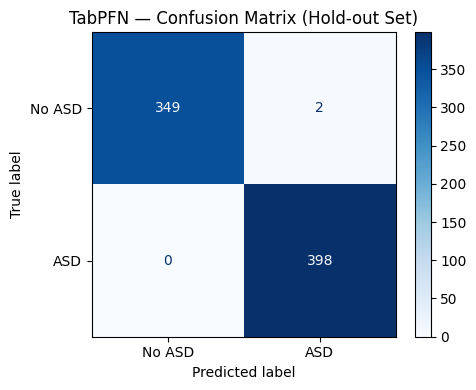

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred,
    display_labels=['No ASD', 'ASD'],
    cmap='Blues',
    ax=ax
)
ax.set_title('TabPFN — Confusion Matrix (Hold-out Set)')
plt.tight_layout()
plt.show()

## Step 6: Generate Test Set Predictions

In [ ]:
X_test = test.drop(columns=[target_col], errors='ignore')
test_preds  = clf.predict(X_test)
test_probas = clf.predict_proba(X_test)[:, 1]

results = test.copy()
results['TabPFN_Predicted']   = test_preds
results['TabPFN_Probability'] = test_probas.round(4)

print(f"Test predictions generated: {len(test_preds)} samples")
print(f"Predicted ASD: {test_preds.sum()} | Predicted No ASD: {(test_preds == 0).sum()}")
results[['TabPFN_Predicted', 'TabPFN_Probability']].head(10)

00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
Test predictions generated: 200 samples
Predicted ASD: 91 | Predicted No ASD: 109


,TabPFN_Predicted,TabPFN_Probability
0,0,0.1782
1,0,0.0048
2,0,0.0262
3,1,0.9958
4,1,0.8828
5,0,0.0000
6,1,0.9922
7,0,0.0151
8,0,0.0074
9,1,0.7867
